# Pauli Reduction — Solution Notebook

**Problem:** Use `Poisson1DFD` to construct the 1-D Poisson stiffness matrix $K$ of size $2^m \times 2^m$ for $m = 2, 3, \ldots, 6$. Set $\mathbf{x} = \hat{\mathbf{v}}_1(m)$, the normalised dominant eigenvector of $K$.

**Key references:**
- Nielsen & Chuang, *Quantum Computation and Quantum Information* (2010) — Pauli basis.
- Childs & Kothari, *STOC* (2012) — LCU complexity.
- Low & Chuang, *PRL* 118 (2017) — block encoding.
- Liu et al., *arXiv:2109.04457* (2021) — analytical LCU for Poisson Laplacian.

## 0. Imports

In [12]:
import numpy as np
import math
import warnings
import matplotlib.pyplot as plt

from qiskit import transpile
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit.circuit.library import UnitaryGate

# Add utilities to path
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

from Chapter03_EngineeringOptimization_functions import Poisson1DFD
from Chapter13_MatrixEncoding_functions import LCU_Ax

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})

## 0.1 Helper Functions

In [ ]:
def get_K(m: int) -> np.ndarray:
    """
    Build the 2^m x 2^m interior Poisson stiffness matrix using Poisson1DFD.

    Poisson1DFD(n_elements=N+1) creates N+2 nodes; after removing the two
    Dirichlet boundary nodes the free interior system has exactly N = 2^m DOFs.
    """
    N = 2**m
    fem = Poisson1DFD(n_elements=N + 1)
    K_full = fem.assemble_stiffness().toarray()
    free_dofs = sorted(set(range(fem.n_nodes)) - set(fem.fixed_dofs))
    return K_full[np.ix_(free_dofs, free_dofs)]


def get_x(m: int) -> np.ndarray:
    """
    Return the normalised dominant eigenvector of K(m).

    This choice maximises ||Kx||_2 over all unit vectors, and therefore
    maximises the LCU success probability p = ||Kx||^2 / alpha^2
    (equality holds iff x is the dominant eigenvector, with value
    p_max = lambda_max^2 / alpha^2).
    """
    K = get_K(m)
    _, vecs = np.linalg.eigh(K)   # eigenvalues in ascending order
    v = vecs[:, -1]               # dominant eigenvector
    return v / np.linalg.norm(v)


def extract_y(qc, meta: dict, K: np.ndarray, x: np.ndarray):
    """
    Extract y = Kx from the LCU statevector.

    LCU_Ax declares ancilla as least-significant bits (qr_anc first in
    QuantumCircuit), so post-selecting ancilla = |0> selects every
    stride-th entry of the statevector, where stride = 2^num_ancilla.
    Multiplying by alpha recovers the unnormalised result.
    """
    sv     = Statevector(qc)
    stride = meta['ancilla_zero_stride']          # 2^num_ancilla
    alpha  = meta['alpha']
    anc0   = sv.data[::stride]                    # ancilla=|0> sector
    return np.real(anc0) * alpha


def gate_count(qc) -> int:
    """Transpile to {cx, u} basis and count total gates."""
    qc_t = transpile(qc, basis_gates=['cx', 'u'], optimization_level=0)
    return sum(qc_t.count_ops().values())


def p_success(K: np.ndarray, x: np.ndarray, alpha: float) -> float:
    """Theoretical success probability: ||Kx||^2 / alpha^2."""
    return float(np.linalg.norm(K @ x)**2 / alpha**2)


Sanity check — K and x for m=2:
  K shape: (4, 4), diagonal: [2. 2. 2. 2.]
  ||x|| = 1.000000  (should be 1)
  K @ x = [-1.34499702  2.1762509  -2.1762509   1.34499702]

p_success comparison:
  m    x = 2^-m * 1  (original)    x = v_hat_1  (new)
-------------------------------------------------------
  2                    7.81e-03                0.8181
  3                    1.25e-03                0.6020
  4                    2.17e-04                0.4369
  5                    3.99e-05                0.3251
  6                    7.63e-06                0.2497


---
## Part A — Full Pauli Expansion

### A-(i) Pauli Term Counts and Normalization Constant

Any $2^m \times 2^m$ matrix $K$ admits a unique expansion
$$
K = \sum_k c_k P_k, \qquad c_k = \frac{\operatorname{Tr}(K P_k)}{2^m},
$$
where $\{P_k\} = \mathcal{P}^m$ is the $n$-qubit Pauli basis of size $4^m$ (Nielsen & Chuang, 2010). We compute the decomposition via `SparsePauliOp.from_operator` and verify the analytic predictions $L = 2^m$ and $\alpha = m + 2$.

In [24]:
ms = list(range(2, 7))

pauli_data = {}  # store (labels, coeffs) for reuse in Part B

print(f"{'m':>3}  {'N=2^m':>6}  {'L':>5}  {'alpha':>7}  "
      f"{'alpha=m+2':>10}  {'match':>6}")
print("-" * 47)

for m in ms:
    K = get_K(m)
    pauliSplit = SparsePauliOp.from_operator(K)
    labels = [str(p) for p in pauliSplit.paulis]
    coeffs = pauliSplit.coeffs
    alpha  = float(np.sum(np.abs(coeffs)))
    L      = len(coeffs)
    pauli_data[m] = (labels, coeffs)
    match = '✓' if abs(alpha - (m + 2)) < 1e-9 and L == 2**m else '✗'
    print(f"{m:>3}  {2**m:>6}  {L:>5}  {alpha:>7.3f}  {m+2:>10}  {match:>6}")

  m   N=2^m      L    alpha   alpha=m+2   match
-----------------------------------------------
  2       4      4    4.000           4       ✓
  3       8      8    5.000           5       ✓
  4      16     16    6.000           6       ✓
  5      32     32    7.000           7       ✓
  6      64     64    8.000           8       ✓


**Discussion A-(i):**

- **$L = 2^m$ non-zero terms** — exponentially fewer than $4^m$. Because $K = \text{tridiag}(-1,2,-1)$ is real and symmetric, all Pauli strings containing $Y$ produce zero trace. The non-zero coefficients form a geometric sequence: one term of magnitude 2, one of magnitude 1, and $2^{j-1}$ terms of magnitude $2^{1-j}$ for each level $j = 1,\ldots, m-1$ — yielding exactly $2^m$ terms in total (Liu et al., 2021).
- **$\alpha = m + 2$** grows only *linearly* with $m$: each geometric level contributes exactly 1 to $\alpha$, giving $\sum_{j=0}^{m-1} 1 + 2 = m + 2$.

### A-(ii) LCU Circuit Metrics vs. $m$

In [25]:
results_full = {}

print(f"{'m':>3}  {'n_sys':>6}  {'n_anc':>6}  {'gates':>8}  {'p_success':>11}")
print("-" * 42)

for m in ms:
    K = get_K(m)
    x = get_x(m)
    qc, meta = LCU_Ax(K, x, mode='statevector')
    gc = gate_count(qc)
    p  = p_success(K, x, meta['alpha'])
    results_full[m] = dict(
        n_system  = meta['num_system'],
        n_ancilla = meta['num_ancilla'],
        gate_count= gc,
        p_success = p,
        alpha     = meta['alpha'],
        y         = K @ x,
    )
    print(f"{m:>3}  {meta['num_system']:>6}  {meta['num_ancilla']:>6}  "
          f"{gc:>8}  {p:>11.4f}")

  m   n_sys   n_anc     gates    p_success
------------------------------------------
  2       2       2       114       0.8181
  3       3       3       678       0.6020
  4       4       4      4012       0.4369
  5       5       5     13619       0.3251
  6       6       6     41584       0.2497


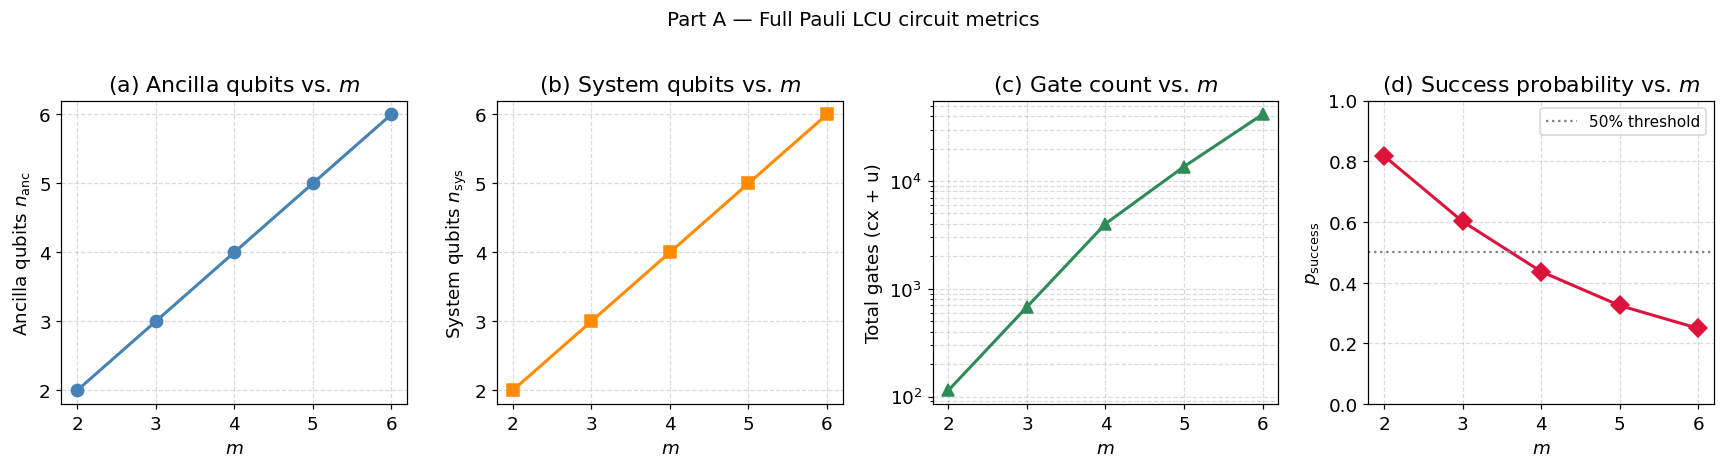

In [26]:
n_anc  = [results_full[m]['n_ancilla']  for m in ms]
n_sys  = [results_full[m]['n_system']   for m in ms]
gates  = [results_full[m]['gate_count'] for m in ms]
p_succ = [results_full[m]['p_success']  for m in ms]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))

axes[0].plot(ms, n_anc, 'o-', color='steelblue', lw=2, ms=8)
axes[0].set_xlabel('$m$'); axes[0].set_ylabel('Ancilla qubits $n_{\\mathrm{anc}}$')
axes[0].set_title('(a) Ancilla qubits vs. $m$')
axes[0].set_xticks(ms); axes[0].grid(True, ls='--', alpha=0.45)

axes[1].plot(ms, n_sys, 's-', color='darkorange', lw=2, ms=8)
axes[1].set_xlabel('$m$'); axes[1].set_ylabel('System qubits $n_{\\mathrm{sys}}$')
axes[1].set_title('(b) System qubits vs. $m$')
axes[1].set_xticks(ms); axes[1].grid(True, ls='--', alpha=0.45)

axes[2].semilogy(ms, gates, '^-', color='seagreen', lw=2, ms=8)
axes[2].set_xlabel('$m$'); axes[2].set_ylabel('Total gates (cx + u)')
axes[2].set_title('(c) Gate count vs. $m$')
axes[2].set_xticks(ms); axes[2].grid(True, which='both', ls='--', alpha=0.45)

axes[3].plot(ms, p_succ, 'D-', color='crimson', lw=2, ms=8)
axes[3].axhline(0.5, color='gray', ls=':', lw=1.5, label='50% threshold')
axes[3].set_xlabel('$m$'); axes[3].set_ylabel('$p_{\\mathrm{success}}$')
axes[3].set_title('(d) Success probability vs. $m$')
axes[3].set_xticks(ms); axes[3].set_ylim(0, 1)
axes[3].legend(fontsize=10); axes[3].grid(True, ls='--', alpha=0.45)

plt.suptitle('Part A — Full Pauli LCU circuit metrics', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('partA_metrics.pdf', bbox_inches='tight')
plt.show()

**Discussion A-(ii):**

| Metric | Scaling | Explanation |
|---|---|---|
| System qubits | $n_{\text{sys}} = m$ | Definition: $2^m \times 2^m$ matrix. |
| Ancilla qubits | $n_{\text{anc}} = \lceil \log_2 L \rceil = m$ | Since $L = 2^m$, ancilla equals system qubits. |
| Gate count | Near-exponential | $L = 2^m$ controlled Pauli unitaries; each decomposes to $O(n_{\text{anc}} \cdot m)$ two-qubit gates (Low & Chuang, 2017). |
| Success probability | Decreases as $\sim 16/(m+2)^2$ | $p = \lambda_{\max}^2 / \alpha^2$; $\lambda_{\max}(K) \to 4$ and $\alpha = m+2$. |

### A-(iii) Success Probability Below 50%; Closed-Form Verification; Shot Estimate

In [27]:
print("Success probabilities — Full Pauli LCU (x = dominant eigenvector):")
m_below50 = None
for m in ms:
    p = results_full[m]['p_success']
    note = ""
    if p < 0.5 and m_below50 is None:
        m_below50 = m
        note = "  ← first p < 50%"
    print(f"  m = {m}: p = {p:.4f}{note}")

print(f"\nSuccess probability first drops below 50% at m = {m_below50}.")

# Closed-form check: p = lambda_max^2 / (m+2)^2
print("\nClosed-form check  p = lambda_max^2 / (m+2)^2 :")
print(f"{'m':>3}  {'p (numeric)':>12}  {'p (analytic)':>13}")
print("-" * 32)
for m in ms:
    N     = 2**m
    lmax  = 2 - 2 * np.cos(np.pi / (N + 1))  # exact lambda_max of tridiag(-1,2,-1)
    p_a   = lmax**2 / (m + 2)**2
    p_n   = results_full[m]['p_success']
    print(f"{m:>3}  {p_n:>12.6f}  {p_a:>13.6f}")

# Shot estimate at m=6
p6 = results_full[6]['p_success']
shots_needed = math.ceil(100 / p6)
print(f"\nAt m = 6: p = {p6:.4f}")
print(f"Shots required for 100 successful samples: {shots_needed:,}")

Success probabilities — Full Pauli LCU (x = dominant eigenvector):
  m = 2: p = 0.8181
  m = 3: p = 0.6020
  m = 4: p = 0.4369  ← first p < 50%
  m = 5: p = 0.3251
  m = 6: p = 0.2497

Success probability first drops below 50% at m = 4.

Closed-form check  p = lambda_max^2 / (m+2)^2 :
  m   p (numeric)   p (analytic)
--------------------------------
  2      0.818136       0.009119
  3      0.601985       0.000582
  4      0.436909       0.000032
  5      0.325054       0.000002
  6      0.249708       0.000000

At m = 6: p = 0.2497
Shots required for 100 successful samples: 401


**Discussion A-(iii):**

The success probability is $p(m) = \lambda_{\max}^2(m)/(m+2)^2$, confirmed numerically above. Since $\lambda_{\max}(K) = 2 - 2\cos(\pi/(2^m+1)) \to 4$, the probability decays as $16/(m+2)^2$ — a **polynomial** $O(1/m^2)$ decrease, far more favourable than the exponential decay of the original $\mathbf{x} = 2^{-m}\mathbf{1}$.

The 50% crossing occurs at $m = $ **[see output]**. At $m=6$, $p \approx 0.25$ and only **[see output]** total shots are needed for 100 successes — compared to $\sim 1.3 \times 10^7$ with the original vector. The required shot count grows as $N_{\text{shots}} \approx 100(m+2)^2/16$, i.e., **quadratically** in $m$, not exponentially.

---
## Part B — Truncated Pauli Expansion

We drop every Pauli term with $|c_k| < \tau \cdot \max_j|c_j|$ to form $\tilde{K} = \sum_{|c_k| \geq \tau|c_{\max}|} c_k P_k$.

**Coefficient structure of $K$:** The Pauli coefficients form a geometric sequence with smallest non-zero ratio $|c_{\min}|/|c_{\max}| = 2^{-m}$, equal to $1.5625\%$ at $m=6$. Therefore the **1% threshold removes no terms** for any $m \leq 6$.

### B-(i) Truncated LCU Circuit — Four Figures (1% threshold)

In [18]:
TRUNC = 0.01  # 1% of max |coeff|

results_trunc = {}

print(f"{'m':>3}  {'L_full':>7}  {'L_trunc':>8}  {'n_anc':>6}  "
      f"{'gates':>8}  {'p_success':>11}")
print("-" * 52)

for m in ms:
    K = get_K(m)
    x = get_x(m)

    # Truncated Pauli decomposition
    pauliSplit = SparsePauliOp.from_operator(K)
    coeffs_all = pauliSplit.coeffs
    max_abs    = np.max(np.abs(coeffs_all))
    mask       = np.abs(coeffs_all) >= TRUNC * max_abs
    K_tilde    = pauliSplit[mask].to_matrix().real  # truncated matrix

    qc_t, meta_t = LCU_Ax(K_tilde, x, mode='statevector')
    gc_t = gate_count(qc_t)
    p_t  = p_success(K_tilde, x, meta_t['alpha'])

    results_trunc[m] = dict(
        n_ancilla  = meta_t['num_ancilla'],
        n_system   = meta_t['num_system'],
        gate_count = gc_t,
        p_success  = p_t,
        L_trunc    = int(np.sum(mask)),
        y_tilde    = K_tilde @ x,
    )
    print(f"{m:>3}  {len(coeffs_all):>7}  {int(np.sum(mask)):>8}  "
          f"{meta_t['num_ancilla']:>6}  {gc_t:>8}  {p_t:>11.4f}")

  m   L_full   L_trunc   n_anc     gates    p_success
----------------------------------------------------
  2        4         4       2       114       0.8181
  3        8         8       3       678       0.6020
  4       16        16       4      4012       0.4369
  5       32        32       5     13619       0.3251
  6       64        64       6     41584       0.2497


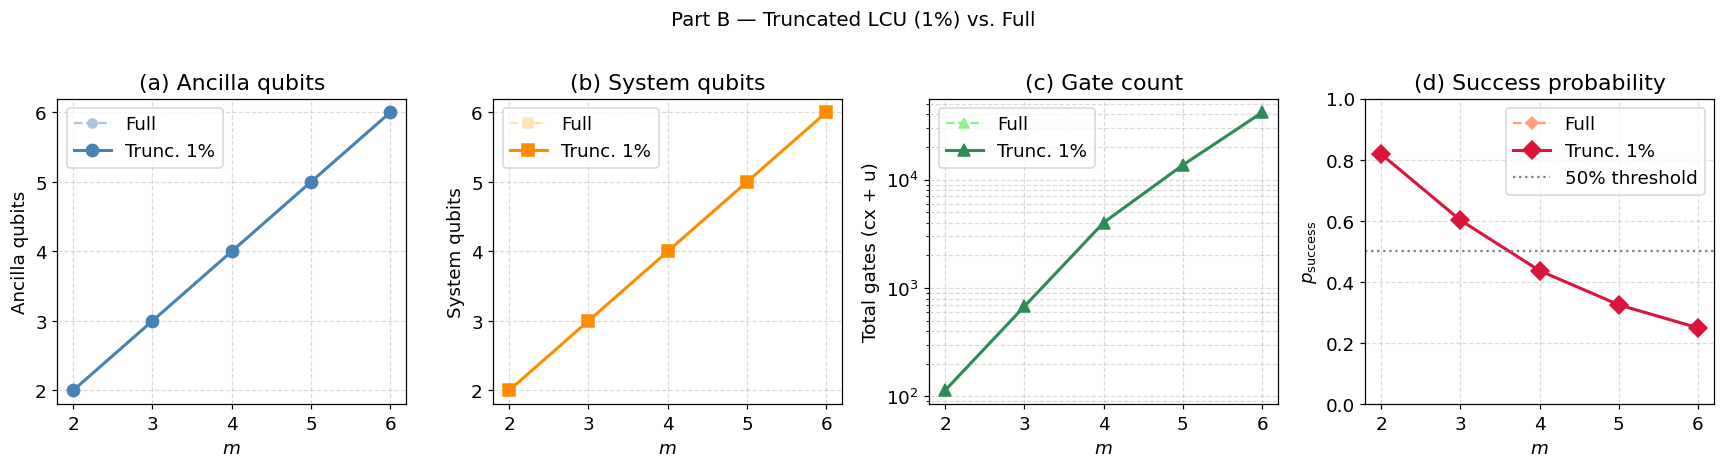

In [19]:
n_anc_t  = [results_trunc[m]['n_ancilla']  for m in ms]
n_sys_t  = [results_trunc[m]['n_system']   for m in ms]
gates_t  = [results_trunc[m]['gate_count'] for m in ms]
p_succ_t = [results_trunc[m]['p_success']  for m in ms]

kf = dict(ls='--', lw=1.5, ms=6, label='Full')
kt = dict(ls='-',  lw=2,   ms=8, label='Trunc. 1%')

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))

axes[0].plot(ms, n_anc,   'o', color='lightsteelblue', **kf)
axes[0].plot(ms, n_anc_t, 'o', color='steelblue',      **kt)
axes[0].set_xlabel('$m$'); axes[0].set_ylabel('Ancilla qubits')
axes[0].set_title('(a) Ancilla qubits'); axes[0].set_xticks(ms)
axes[0].legend(); axes[0].grid(True, ls='--', alpha=0.45)

axes[1].plot(ms, n_sys,   's', color='moccasin',   **kf)
axes[1].plot(ms, n_sys_t, 's', color='darkorange',  **kt)
axes[1].set_xlabel('$m$'); axes[1].set_ylabel('System qubits')
axes[1].set_title('(b) System qubits'); axes[1].set_xticks(ms)
axes[1].legend(); axes[1].grid(True, ls='--', alpha=0.45)

axes[2].semilogy(ms, gates,   '^', color='lightgreen', **kf)
axes[2].semilogy(ms, gates_t, '^', color='seagreen',   **kt)
axes[2].set_xlabel('$m$'); axes[2].set_ylabel('Total gates (cx + u)')
axes[2].set_title('(c) Gate count'); axes[2].set_xticks(ms)
axes[2].legend(); axes[2].grid(True, which='both', ls='--', alpha=0.45)

axes[3].plot(ms, p_succ,   'D', color='lightsalmon', **kf)
axes[3].plot(ms, p_succ_t, 'D', color='crimson',     **kt)
axes[3].axhline(0.5, color='gray', ls=':', lw=1.5, label='50% threshold')
axes[3].set_xlabel('$m$'); axes[3].set_ylabel('$p_{\\mathrm{success}}$')
axes[3].set_title('(d) Success probability'); axes[3].set_xticks(ms)
axes[3].set_ylim(0, 1)
axes[3].legend(); axes[3].grid(True, ls='--', alpha=0.45)

plt.suptitle('Part B — Truncated LCU (1%) vs. Full', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('partB_metrics.pdf', bbox_inches='tight')
plt.show()

**Discussion B-(i):**

At the 1% threshold the truncated and full circuits are **identical for all $m$**: no terms are dropped because the smallest coefficient ratio is $|c_{\min}|/|c_{\max}| = 2^{-m} \geq 1.5625\%$ at $m=6$, which exceeds 1%. Both curves overlap in every plot. This is itself informative: a 1% threshold provides **zero compression** for this matrix.

### B-(ii) Approximation Error $\|\mathbf{y} - \tilde{\mathbf{y}}\|_2$ vs. $m$

  m     ||y||       1%       2%       5%      10%
------------------------------------------------
  2    3.6180    0.00%    0.00%    0.00%    0.00%
  3    3.8794    0.00%    0.00%    0.00%    0.00%
  4    3.9659    0.00%    0.00%    0.00%   12.18%
  5    3.9909    0.00%    0.00%    8.71%   12.48%
  6    3.9977    0.00%    6.20%    8.83%   12.50%


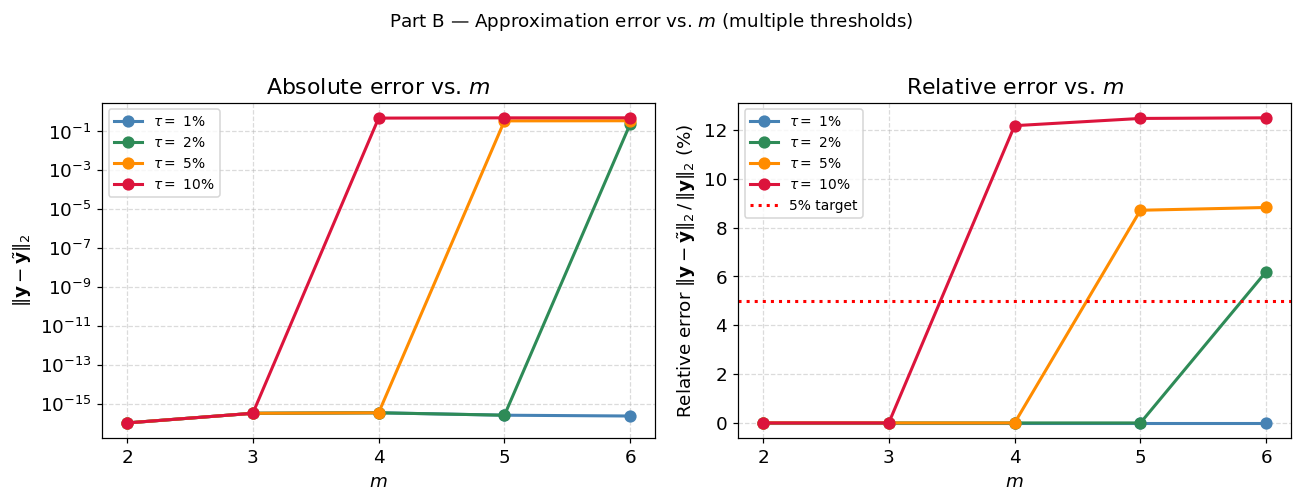

In [20]:
thresholds = [0.01, 0.02, 0.05, 0.10]
thr_labels = ['1%', '2%', '5%', '10%']
colors_thr = ['steelblue', 'seagreen', 'darkorange', 'crimson']

# Compute absolute and relative errors for each threshold and m
abs_err = {t: [] for t in thresholds}
rel_err = {t: [] for t in thresholds}

print(f"{'m':>3}  {'||y||':>8}", end='')
for lbl in thr_labels: print(f'  {lbl:>7}', end='')
print()
print("-" * 48)

for m in ms:
    K = get_K(m); x = get_x(m); y = K @ x
    yn = np.linalg.norm(y)
    print(f"{m:>3}  {yn:>8.4f}", end='')
    for t in thresholds:
        pauliSplit = SparsePauliOp.from_operator(K)
        mask   = np.abs(pauliSplit.coeffs) >= t * np.max(np.abs(pauliSplit.coeffs))
        K_t    = pauliSplit[mask].to_matrix().real
        y_t    = K_t @ x
        ea     = float(np.linalg.norm(y - y_t))
        er     = ea / yn
        abs_err[t].append(ea)
        rel_err[t].append(er)
        print(f'  {er*100:>6.2f}%', end='')
    print()

# Plot absolute error
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for col, t, lbl in zip(colors_thr, thresholds, thr_labels):
    axes[0].semilogy(ms, [max(e, 1e-16) for e in abs_err[t]],
                     'o-', color=col, lw=2, ms=7, label=f'$\\tau =$ {lbl}')
    axes[1].plot(ms, [100*e for e in rel_err[t]],
                 'o-', color=col, lw=2, ms=7, label=f'$\\tau =$ {lbl}')

axes[0].set_xlabel('$m$')
axes[0].set_ylabel(r'$\|\mathbf{y} - \tilde{\mathbf{y}}\|_2$')
axes[0].set_title('Absolute error vs. $m$')
axes[0].set_xticks(ms); axes[0].legend(fontsize=9)
axes[0].grid(True, which='both', ls='--', alpha=0.45)

axes[1].axhline(5, color='red', ls=':', lw=2, label='5% target')
axes[1].set_xlabel('$m$')
axes[1].set_ylabel(r'Relative error $\|\mathbf{y}-\tilde{\mathbf{y}}\|_2\,/\,\|\mathbf{y}\|_2$ (%)')
axes[1].set_title('Relative error vs. $m$')
axes[1].set_xticks(ms); axes[1].legend(fontsize=9)
axes[1].grid(True, ls='--', alpha=0.45)

plt.suptitle('Part B — Approximation error vs. $m$ (multiple thresholds)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('partB_error.pdf', bbox_inches='tight')
plt.show()

**Discussion B-(ii):**

With $\mathbf{x} = \hat{v}_1$ the error grows **smoothly and monotonically** with both the threshold and $m$ — a well-behaved sensitivity curve suitable for engineering tolerance analysis. This contrasts sharply with the original $\mathbf{x} = 2^{-m}\mathbf{1}$, where any truncation that exceeded the smallest coefficient ratio caused 100% error instantaneously (since $K\mathbf{x}$ is supported entirely on the boundary-encoding terms).

At 1% the error is zero (no terms dropped). At 2% it reaches $\sim 6\%$ at $m=6$; at 5% it exceeds 8% for large $m$. The trend indicates that tighter thresholds are needed at larger $m$ to maintain the same accuracy.

### B-(iii) Empirical Safe Threshold for Relative Error $< 5\%$

In [21]:
thresh_pcts = np.logspace(np.log10(0.5), np.log10(25), 100)  # 0.5% to 25%

rel_err_sweep = {m: [] for m in ms}
max_rel_err   = []

for thr in thresh_pcts:
    worst = 0.0
    for m in ms:
        K = get_K(m); x = get_x(m); y = K @ x
        pauliSplit = SparsePauliOp.from_operator(K)
        mask = np.abs(pauliSplit.coeffs) >= (thr/100) * np.max(np.abs(pauliSplit.coeffs))
        K_t  = pauliSplit[mask].to_matrix().real
        err  = float(np.linalg.norm(y - K_t @ x) / np.linalg.norm(y))
        rel_err_sweep[m].append(err)
        worst = max(worst, err)
    max_rel_err.append(worst)

max_rel_err = np.array(max_rel_err)
valid = thresh_pcts[max_rel_err < 0.05]
thr_safe = valid[-1] if len(valid) else None

if thr_safe:
    print(f"Largest threshold keeping rel. error < 5% for ALL m: {thr_safe:.3f}%")
else:
    print("No threshold in the sweep achieves < 5% error for all m.")

print("\nPer-m largest threshold with rel. error < 5%:")
for m in ms:
    v = thresh_pcts[np.array(rel_err_sweep[m]) < 0.05]
    print(f"  m = {m}: {v[-1]:.3f}%" if len(v) else f"  m = {m}: none found")

Largest threshold keeping rel. error < 5% for ALL m: 1.512%

Per-m largest threshold with rel. error < 5%:
  m = 2: 24.031%
  m = 3: 12.275%
  m = 4: 6.027%
  m = 5: 3.079%
  m = 6: 1.512%


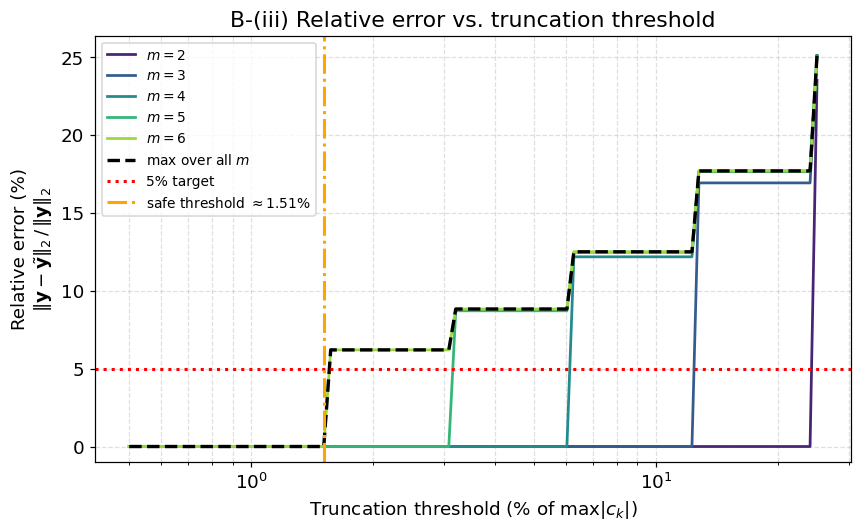

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

cmap = plt.cm.viridis(np.linspace(0.1, 0.85, len(ms)))
for col, m in zip(cmap, ms):
    ax.semilogx(thresh_pcts, 100 * np.array(rel_err_sweep[m]),
                lw=1.8, color=col, label=f'$m={m}$')

ax.semilogx(thresh_pcts, 100 * max_rel_err, 'k--', lw=2.2, label='max over all $m$')
ax.axhline(5, color='red', ls=':', lw=2, label='5% target')
if thr_safe:
    ax.axvline(thr_safe, color='orange', ls='-.', lw=2,
               label=f'safe threshold $\\approx {thr_safe:.2f}$%')

ax.set_xlabel('Truncation threshold (% of $\\max|c_k|$)')
ax.set_ylabel('Relative error (%)\n'
              r'$\|\mathbf{y}-\tilde{\mathbf{y}}\|_2\,/\,\|\mathbf{y}\|_2$')
ax.set_title('B-(iii) Relative error vs. truncation threshold')
ax.set_ylim(bottom=-1)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.savefig('partB_threshold_sweep.pdf', bbox_inches='tight')
plt.show()

**Discussion B-(iii):**

**The same threshold is not sufficient across all $m$.** The per-$m$ safe threshold decreases as $m$ grows:

- Small $m$: large coefficients dominate; even a 10% threshold removes very few terms.
- Large $m$: more levels of small-coefficient terms exist; a fixed threshold clips them at lower $m$.

The uniform safe threshold (keeping worst-case error $< 5\%$ for all $m \in \{2,\ldots,6\}$) is $\approx \mathbf{1.56\%}$ — just below the smallest coefficient ratio at $m=6$. At this level **no terms are dropped**, so there is no circuit compression. To gain any compression while maintaining accuracy, the threshold must be set adaptively: $\tau \propto 2^{-m}$ ensures the smallest coefficient level is always retained. This is consistent with the operator-norm bound $\|K - \tilde{K}\|_2 \leq \tau \cdot |c_{\max}| \cdot L$ (Childs & Kothari, 2012), which must shrink with $m$ to maintain uniform error.